In [1]:
import pandas as pd
df = pd.read_csv('HW01_data.txt', sep='\t')

# View the first few rows
df.head()

,x,y
0,-1.0,-3
1,0.0,-1
2,1.0,1
3,2.0,3
4,3.0,3


In [2]:
x_data = df['x'].values
y_data = df['y'].values

'''
Interpolating function with assummed extrapolation
'''
def interpolation(x, x_data, y_data):

    #Handle extrapolation
    if x < x_data[0]:
        return y_data[0] # Assumption: Constant value from first point
    if x > x_data[-1]:
        return y_data[-1] # Assumption: Constant value from last point

    #Interpolation
    for i in range(len(x_data) - 1):
        if x_data[i] <= x <= x_data[i+1]:
            ai = (y_data[i+1]-y_data[i])/(x_data[i+1]-x_data[i]) #slope
            bi = y_data[i]

            gi_x = ai*(x-x_data[i]) + bi #y
    return gi_x


In [3]:
import numpy as np
'''
10 times higher resolution data
'''
num_points = len(x_data) * 10
#create x values
x = np.linspace(x_data.min(), x_data.max(), num_points) #same min and max as the original data
#corresponding interpolated y values
y = [interpolation(x, x_data, y_data) for x in x]

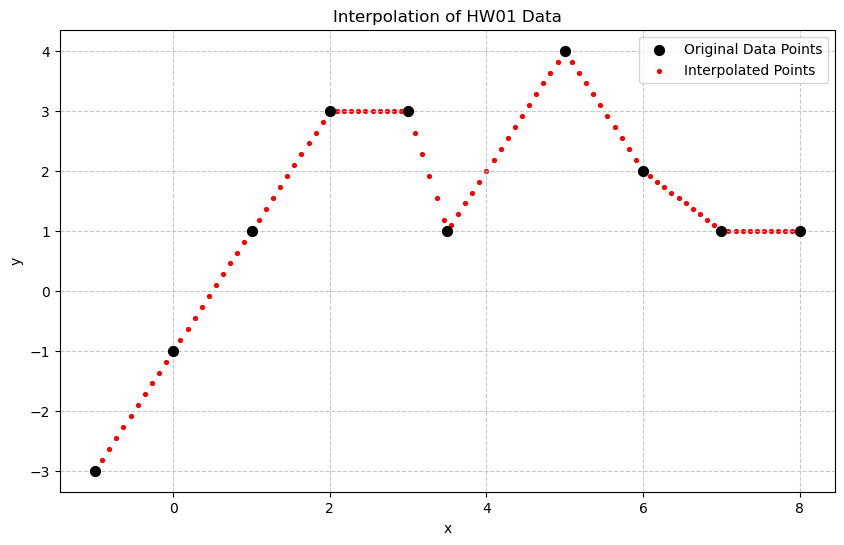

In [4]:
import matplotlib.pyplot as plt
#Plotting
plt.figure(figsize=(10, 6))

# Plot the original dataset
plt.scatter(x_data, y_data, color='black', s=50, zorder=5, label='Original Data Points')

# Plot the interpolated points (and line may be)
plt.scatter(x, y, color='red', s=30, marker='.', label='Interpolated Points')
#plt.plot(x, y, 'b-', label='Interpolation', alpha=0.6)

plt.title('Interpolation of HW01 Data')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [5]:
from scipy.interpolate import CubicSpline
#create cubic spline intrepolation function
cs = CubicSpline(x_data, y_data)
#interpolated y values
y_cs = cs(x)